In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

In [2]:
SMALL_SIZE = 11
MEDIUM_SIZE = 12.5
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

# Gradient Norm Experiments

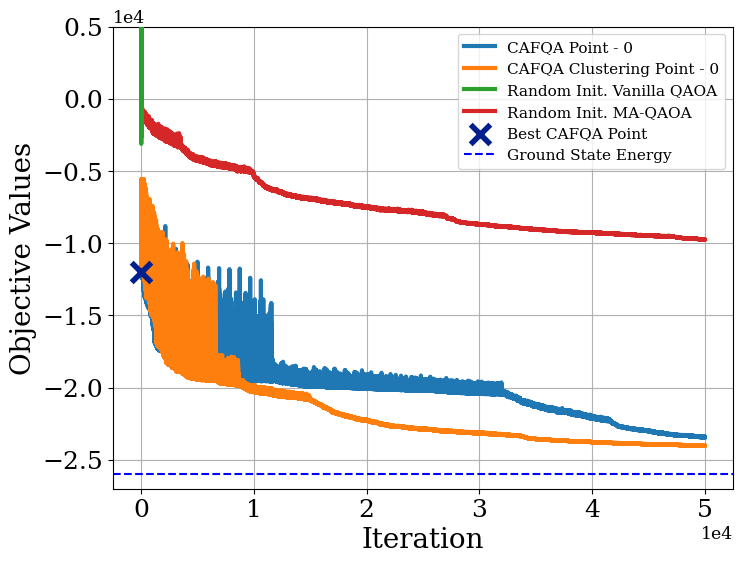

In [3]:
# K-means Gradient Norm - Good example
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Teague/14_qbs/result_41_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')
plt.ylim(-27000,5000)
# plt.xlim(-500,30000)


plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

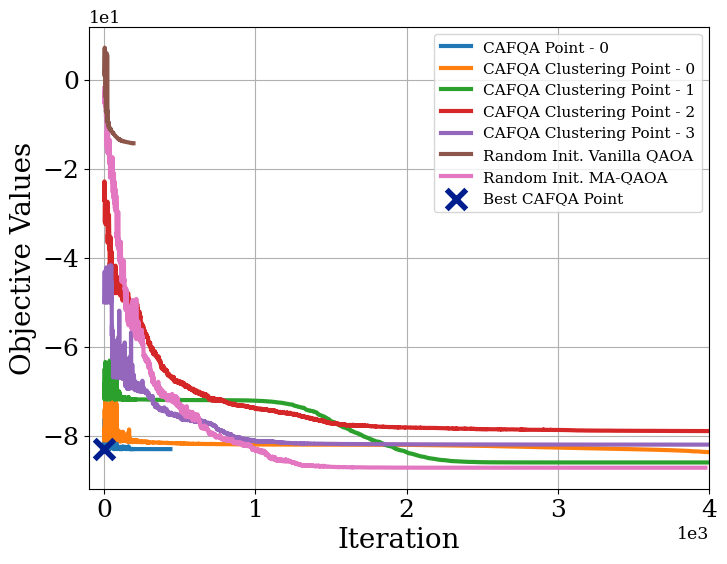

In [4]:
#Maxcut Gradient Norm 

# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/16_qbs/result_5_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(4)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')

plt.xlim(-100,4000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

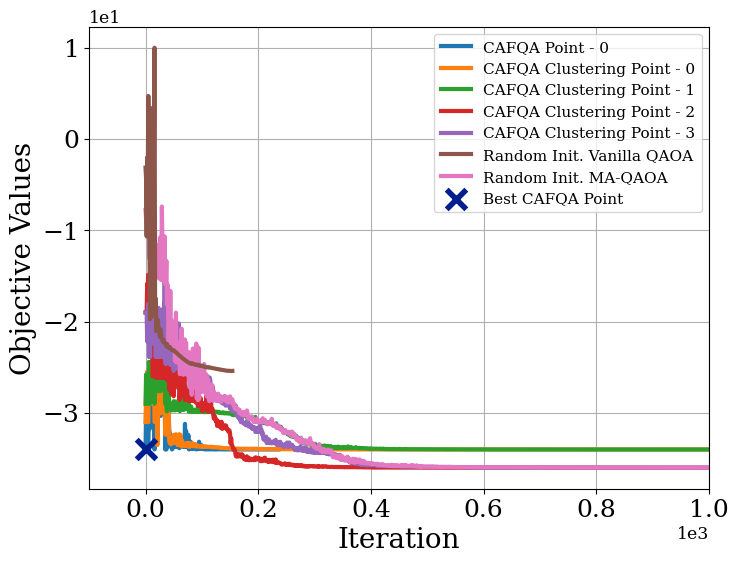

In [5]:
#Maxcut Gradient Norm 

# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/8_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(4)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')
plt.xlim(-100,1000)

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

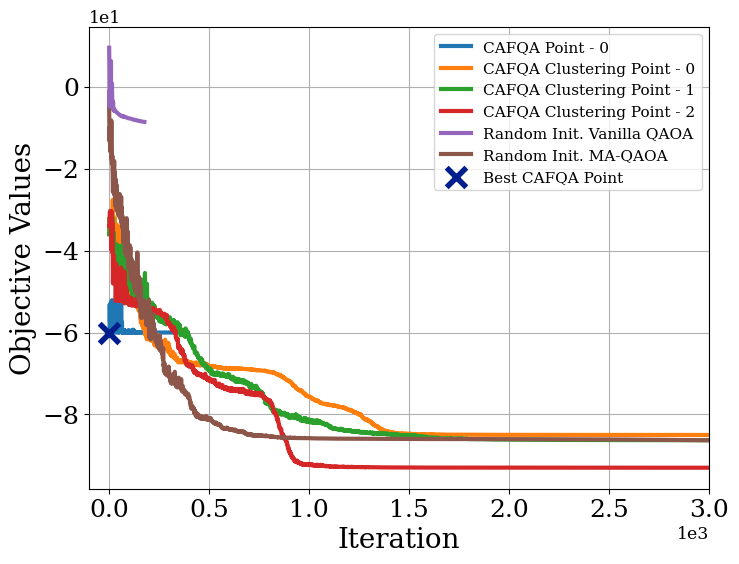

In [6]:
#Maxcut Gradient Norm - Good example

# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(3)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')

plt.xlim(-100,3000)
plt.legend()    
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

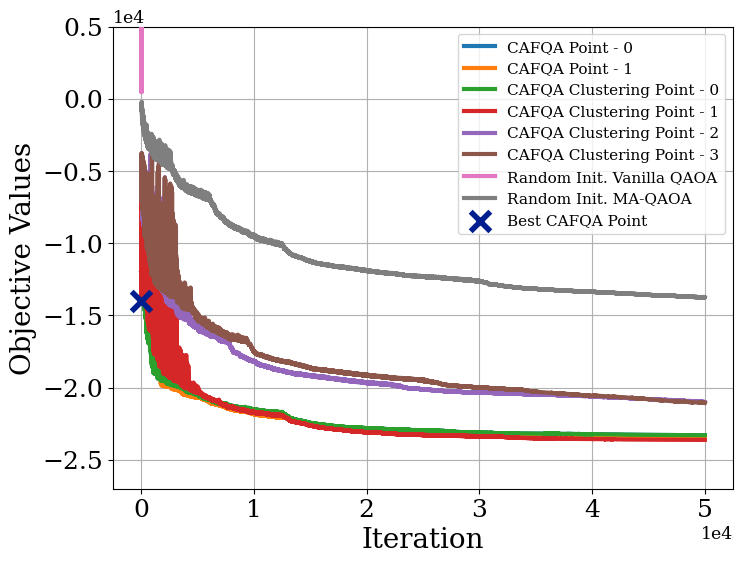

In [7]:
# K-means Gradient Norm - Good
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Teague/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(2)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(4)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
plt.ylim(-27000,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

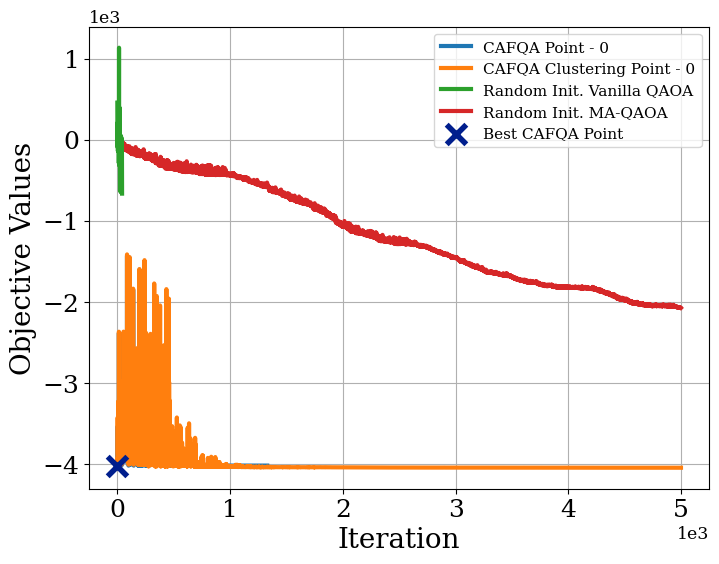

In [8]:
# K-means Gradient Norm 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Knapsack/9_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.ylim(-27000,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

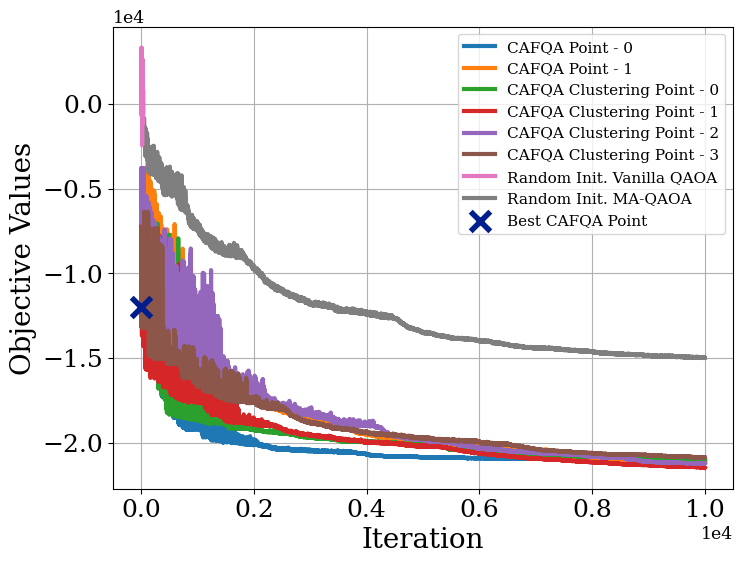

In [9]:
# K-means Gradient Norm 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Teague/10_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(2)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(4)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.ylim(-27000,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

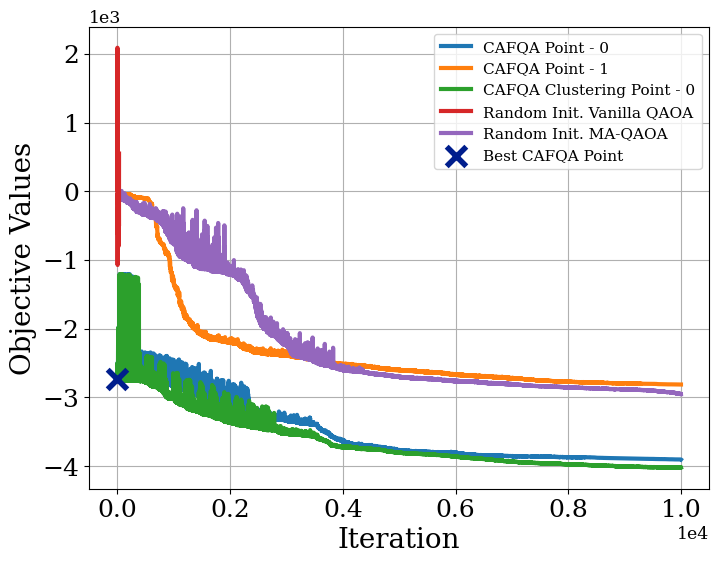

In [10]:
# K-means Gradient Norm - Good 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Knapsack/9_qbs/result_3_clustering_k_means_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(2)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.xlim(-200,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

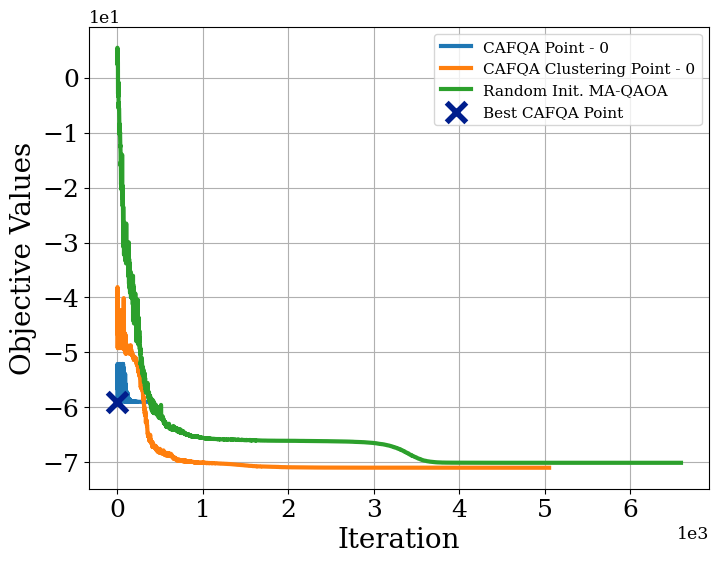

In [11]:
# K-means Gradient Norm 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/14_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.ylim(-27000,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

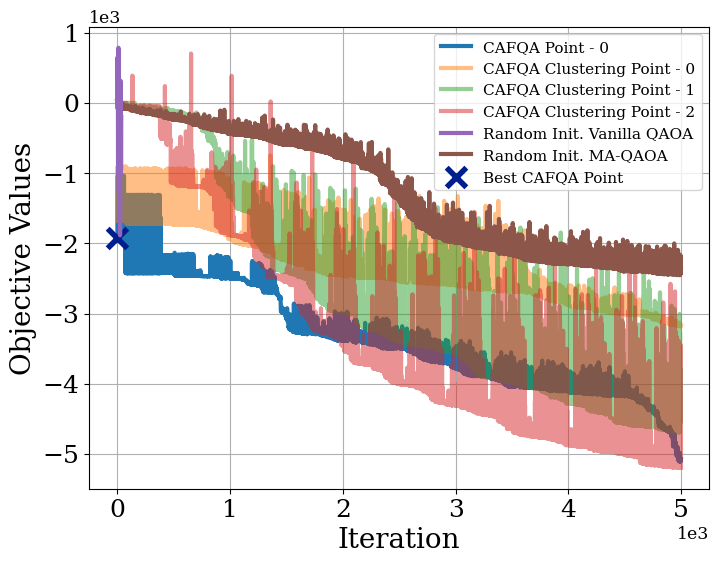

In [12]:
# K-means Gradient Norm 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Knapsack/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(3)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3,alpha=0.5)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

## Noisy


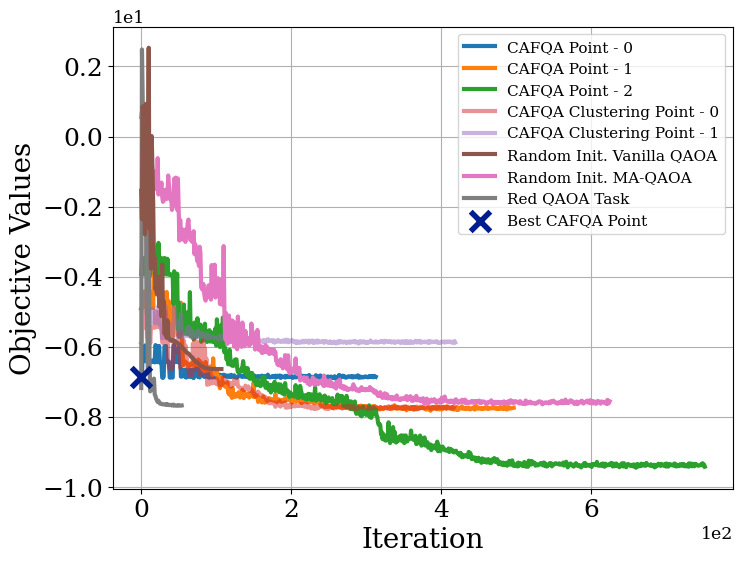

In [13]:

# K-means Gradient Norm #Noisy - Good

# cafqa_diff_points_data['Task_results']['Red_qaoa_task']


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/10_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(3)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(2)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3,alpha=0.5)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red QAOA Task', linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

#NOTE: dont worry about result because cafqa can find better with more gens. also this is unweighted problem.

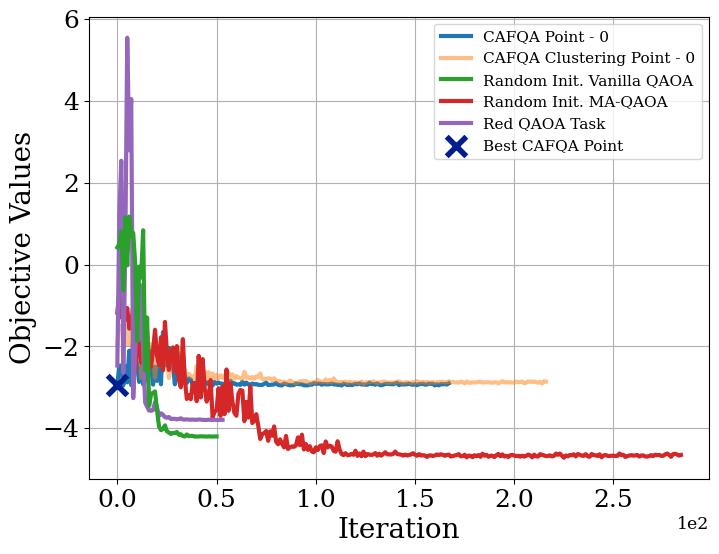

In [14]:

# K-means Gradient Norm #Noisy - bad

# cafqa_diff_points_data['Task_results']['Red_qaoa_task']


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/6_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3,alpha=0.5)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red QAOA Task', linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

#NOTE: dont worry about result because cafqa can find better with more gens. also this is unweighted problem.

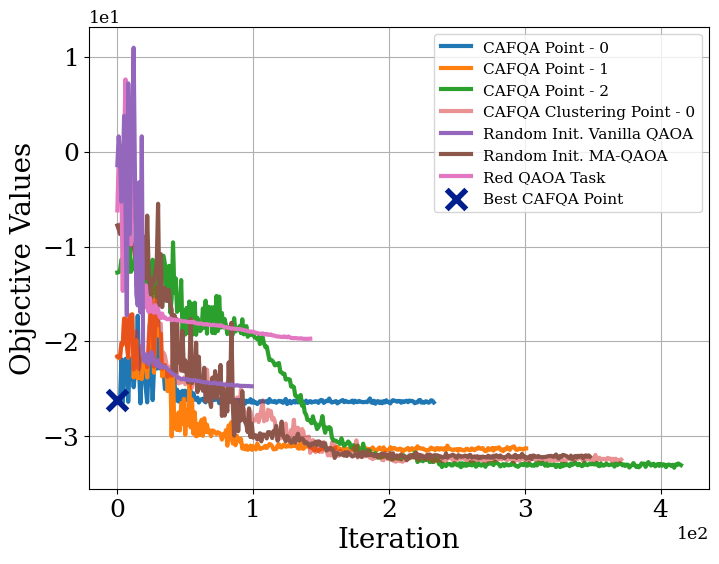

In [15]:

# K-means Gradient Norm #Noisy

cafqa_diff_points_data['Task_results']['Red_qaoa_task']


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/8_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(3)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3,alpha=0.5)

plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red QAOA Task', linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()


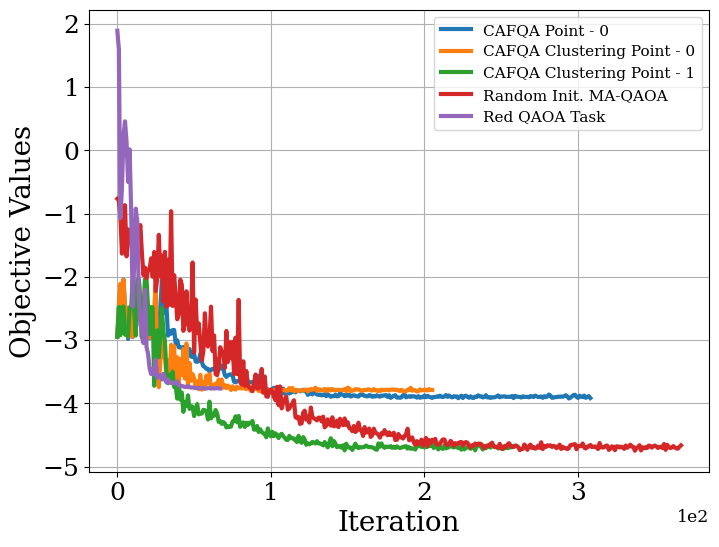

In [16]:

# K-means Gradient Norm #Noisy Final day 

cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/6_qbs/result_3_clustering_k_means_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(2)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'CAFQA Clustering Point - {i}', linewidth=3)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red QAOA Task', linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()


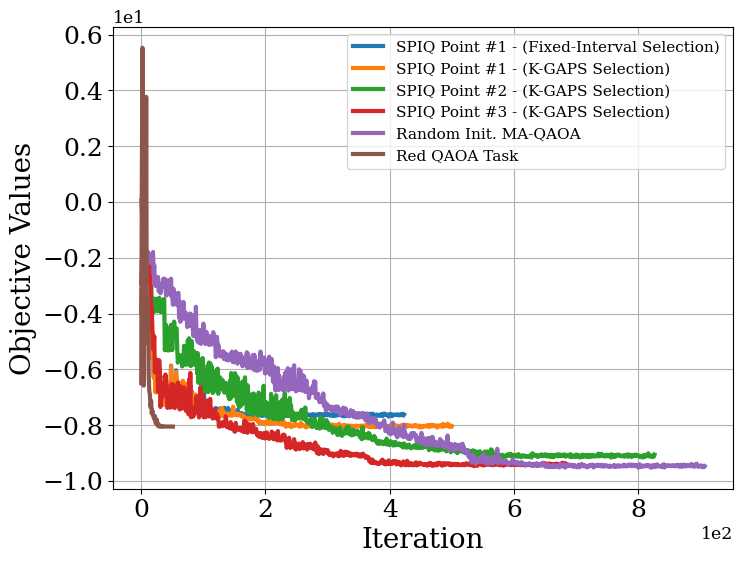

In [18]:

# K-means Gradient Norm #Noisy Final day 

cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(3)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAPS Selection)', linewidth=3)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA',linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red QAOA Task', linewidth=3)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()
